In [1]:
# pip install pandas numpy google-cloud-bigquery db-dtypes pandas-gbq prophet scikit-learn xgboost matplotlib seaborn python-dotenv

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pathlib import Path
from google.oauth2 import service_account
from google.cloud import bigquery

PROJECT_ROOT = Path.cwd().parent
PROJECT_ID = os.environ["GCP_PROJECT_ID"]
GOLD_DATASET = os.environ.get("BQ_GOLD_DATASET", "olist_gold")
load_dotenv(PROJECT_ROOT / ".env")

credentials = service_account.Credentials.from_service_account_file(
    PROJECT_ROOT / "service-account.json"
)

client = bigquery.Client(
    project=PROJECT_ID,
    credentials=credentials
)


def query(sql: str) -> pd.DataFrame:
    """All queries here are SELECT-only (DQL) — free tier / sandbox safe,
    same constraint as the rest of the pipeline."""
    return client.query(sql).to_dataframe()

G = f"`{PROJECT_ID}.{GOLD_DATASET}`"
print("Ready. Gold dataset:", GOLD_DATASET)

Ready. Gold dataset: olist_gold


## 1

In [2]:
df_rev = query(f"""
    SELECT date_day, total_revenue
    FROM {G}.mart_daily_revenue
    WHERE is_synthetic = FALSE
    ORDER BY date_day
""")

from prophet import Prophet

prophet_df = df_rev.rename(columns={"date_day": "ds", "total_revenue": "y"})
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

# Black Friday 2017 shows up as a real spike in the data (~63% jump in Nov
# 2017 vs Oct/Dec) — give Prophet an explicit holiday for it instead of
# relying on yearly_seasonality alone to catch a single-year event.
black_friday = pd.DataFrame({
    "holiday": "black_friday",
    "ds": pd.to_datetime(["2017-11-24"]),
    "lower_window": -3,
    "upper_window": 1,
})

model_revenue = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=black_friday,
)
model_revenue.fit(prophet_df)

future = model_revenue.make_future_dataframe(periods=90)
forecast = model_revenue.predict(future)

c:\Users\Admin\Documents\olist_ecommerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
c:\Users\Admin\Documents\olist_ecommerce\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
23:09:26 - cmdstanpy - INFO - Chain [1] start processing
23:09:27 - cmdstanpy - INFO - Chain [1] done processing


c:\Users\Admin\Documents\olist_ecommerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


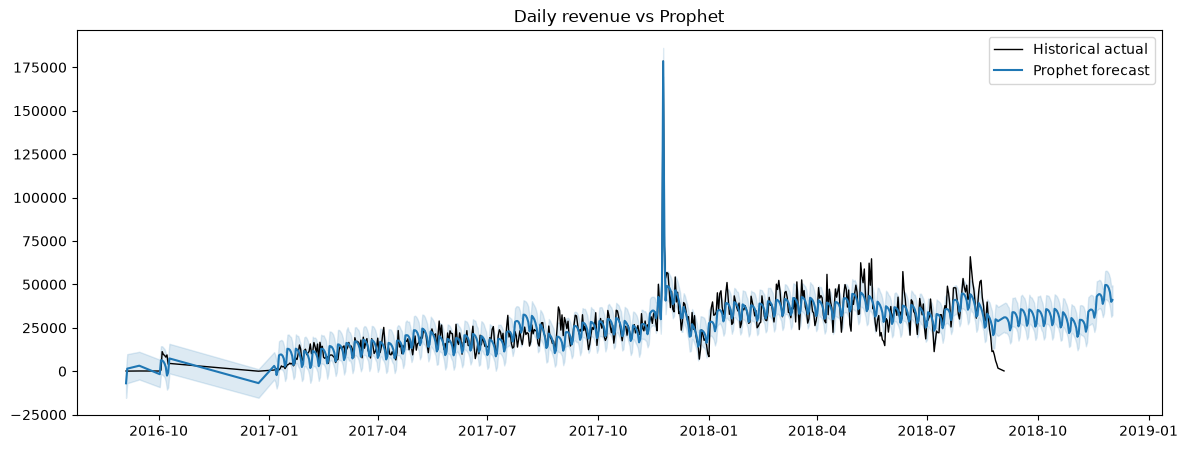

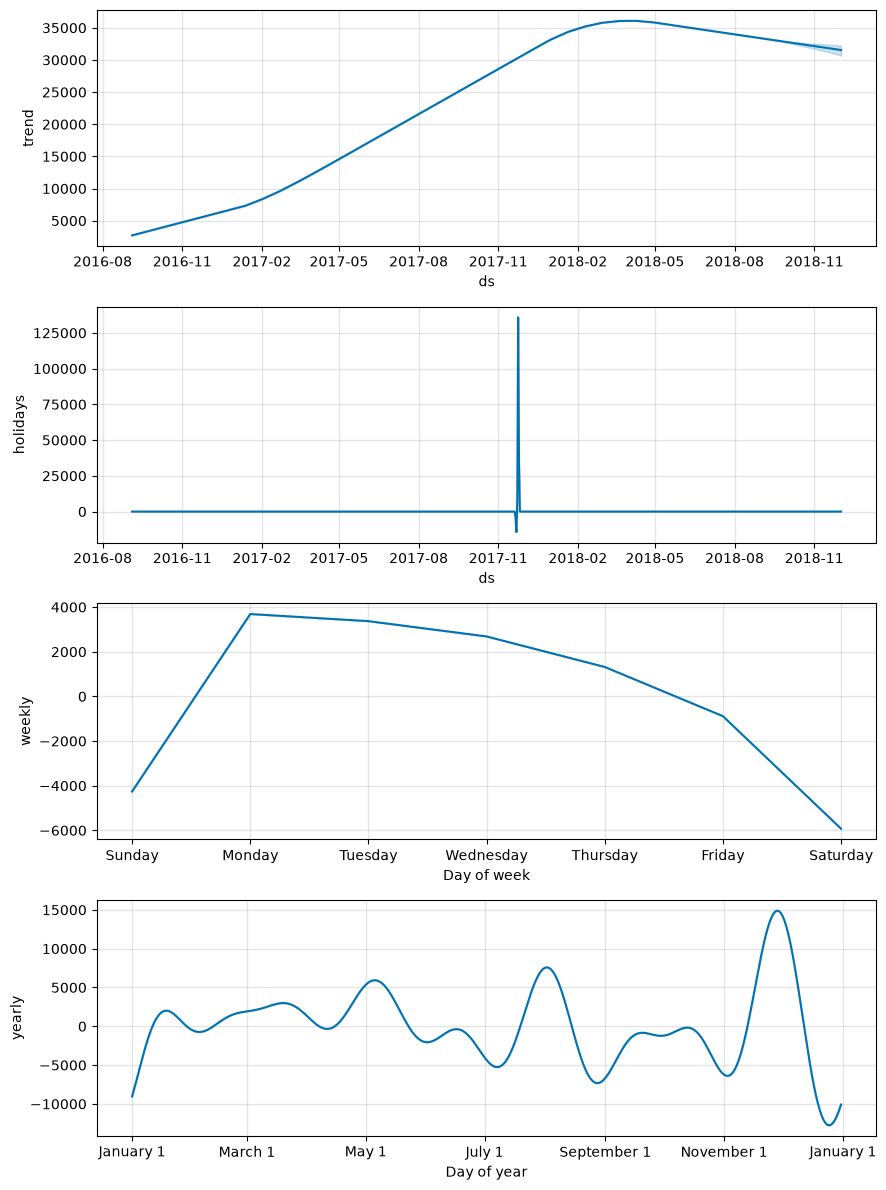

In [4]:
df_synth = query(f"""
    SELECT date_day, total_revenue
    FROM {G}.mart_daily_revenue
    WHERE is_synthetic = TRUE
    ORDER BY date_day
""")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prophet_df["ds"], prophet_df["y"], label="Historical actual", color="black", linewidth=1)
ax.plot(forecast["ds"], forecast["yhat"], label="Prophet forecast", color="tab:blue")
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], alpha=0.15, color="tab:blue")


ax.legend()
ax.set_title("Daily revenue vs Prophet")
plt.show()

model_revenue.plot_components(forecast)
plt.show()

In [5]:
import joblib
joblib.dump(model_revenue, "model_revenue_forecast.pkl")

['model_revenue_forecast.pkl']

## 2

c:\Users\Admin\Documents\olist_ecommerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


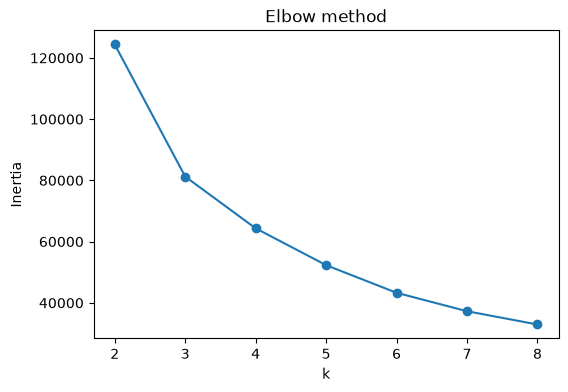

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df_rfm = query(f"""
    SELECT customer_unique_id, recency, monetary, recency_log, monetary_log
    FROM {G}.mart_customer_rfm
    WHERE is_synthetic = FALSE
""")

X = df_rfm[["recency_log", "monetary_log"]].values
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

         n_customers  avg_recency avg_monetary
cluster                                       
0              28149   2895.52247   345.704985
1              30620  3130.795232   115.783478
2              37327  2853.350845    73.199892


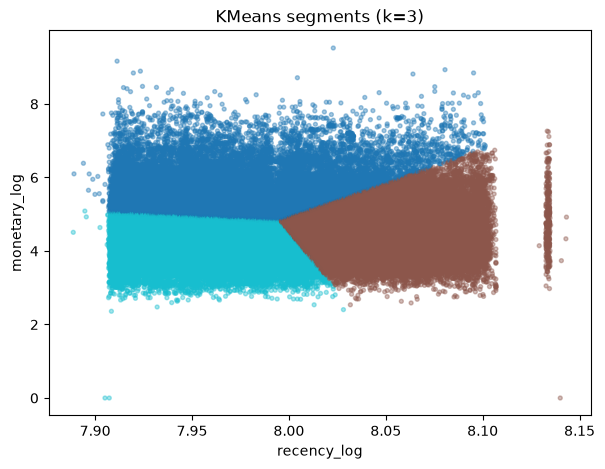

In [8]:
K = 3  # adjust based on the elbow plot above
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)

df_rfm["cluster"] = kmeans.labels_

profile = df_rfm.groupby("cluster").agg(
    n_customers=("customer_unique_id", "count"),
    avg_recency=("recency", "mean"),
    avg_monetary=("monetary", "mean"),
).sort_values("avg_monetary", ascending=False)
print(profile)

plt.figure(figsize=(7, 5))
plt.scatter(df_rfm["recency_log"], df_rfm["monetary_log"], c=df_rfm["cluster"], cmap="tab10", alpha=0.4, s=8)
plt.xlabel("recency_log")
plt.ylabel("monetary_log")
plt.title(f"KMeans segments (k={K})")
plt.show()

In [ ]:
joblib.dump({"scaler": scaler, "kmeans": kmeans}, "model_segmentation.pkl")

['model_segmentation.pkl']

## 3

In [11]:
df_repeat = query(f"""
WITH first_order AS (
    SELECT
        f.customer_unique_id,
        f.order_id AS first_order_id,
        COALESCE(
            f.order_approved_at,
            f.order_purchase_timestamp
        ) AS t,
        f.is_synthetic,
        f.order_purchase_timestamp
    FROM {G}.fct_orders f
    WHERE f.customer_unique_id IS NOT NULL
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY f.customer_unique_id
        ORDER BY f.order_purchase_timestamp
    ) = 1
),

first_order_items AS (
    SELECT
        fo.customer_unique_id,
        fo.first_order_id,
        fo.t,
        fo.is_synthetic,

        SUM(oi.price) AS first_order_price,
        SUM(oi.freight_value) AS first_order_freight,
        COUNT(*) AS first_order_n_items,

        -- Most expensive item's category as first order main category
        ARRAY_AGG(
            p.product_category_name_english
            ORDER BY oi.price DESC
            LIMIT 1
        )[OFFSET(0)] AS first_order_main_category

    FROM first_order fo
    JOIN {G}.fct_order_items oi
        ON oi.order_id = fo.first_order_id
    LEFT JOIN {G}.dim_products p
        ON p.product_id = oi.product_id

    GROUP BY
        fo.customer_unique_id,
        fo.first_order_id,
        fo.t,
        fo.is_synthetic
),

first_order_payment AS (
    SELECT
        order_id,

        -- Take payment type with largest value
        ARRAY_AGG(
            payment_type
            ORDER BY payment_value DESC
            LIMIT 1
        )[OFFSET(0)] AS payment_type,

        MAX(payment_installments) AS payment_installments

    FROM {G}.fct_payments

    GROUP BY order_id
),

label AS (
    SELECT
        fo.customer_unique_id,

        MAX(
            CASE
                WHEN f.order_id != fo.first_order_id
                 AND f.order_purchase_timestamp > fo.t
                THEN 1
                ELSE 0
            END
        ) AS repeat_purchase

    FROM first_order fo

    JOIN {G}.fct_orders f
        ON f.customer_unique_id = fo.customer_unique_id

    GROUP BY fo.customer_unique_id
)

SELECT
    foi.customer_unique_id,
    foi.is_synthetic,

    foi.first_order_price,
    foi.first_order_freight,
    foi.first_order_n_items,
    foi.first_order_main_category,

    fp.payment_type,
    fp.payment_installments,

    EXTRACT(
        DAYOFWEEK FROM foi.t
    ) AS purchase_day_of_week,

    EXTRACT(
        MONTH FROM foi.t
    ) AS purchase_month,

    l.repeat_purchase

FROM first_order_items foi

JOIN first_order_payment fp
    ON fp.order_id = foi.first_order_id

JOIN label l
    ON l.customer_unique_id = foi.customer_unique_id
""")

print(df_repeat.shape)
print(df_repeat["repeat_purchase"].value_counts(normalize=True))

c:\Users\Admin\Documents\olist_ecommerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(99351, 11)
repeat_purchase
0    0.977011
1    0.022989
Name: proportion, dtype: Float64


              precision    recall  f1-score   support

         0.0       0.98      0.57      0.72     18646
         1.0       0.03      0.56      0.06       432

    accuracy                           0.57     19078
   macro avg       0.51      0.56      0.39     19078
weighted avg       0.96      0.57      0.71     19078

PR-AUC: 0.03329923129616168


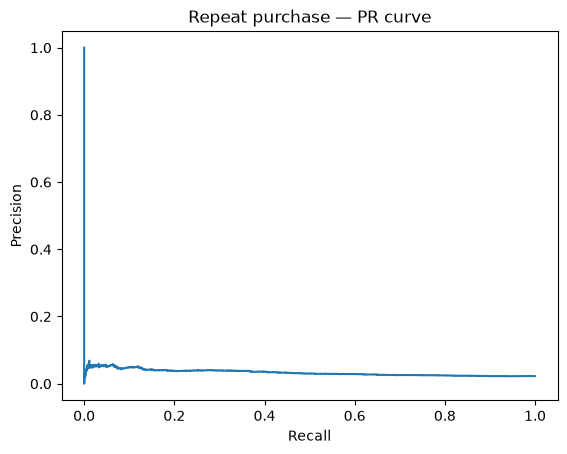

['model_repeat_purchase.pkl']

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve

train_df = df_repeat[df_repeat["is_synthetic"] == False].copy()

num_cols = ["first_order_price", "first_order_freight", "first_order_n_items",
            "payment_installments", "purchase_day_of_week", "purchase_month"]
cat_cols = ["first_order_main_category", "payment_type"]

X = train_df[num_cols + cat_cols]
y = train_df["repeat_purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

clf_repeat = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
clf_repeat.fit(X_train, y_train)

y_proba = clf_repeat.predict_proba(X_test)[:, 1]
y_pred = clf_repeat.predict(X_test)

print(classification_report(y_test, y_pred))
print("PR-AUC:", average_precision_score(y_test, y_proba))

precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Repeat purchase — PR curve")
plt.show()

joblib.dump(clf_repeat, "model_repeat_purchase.pkl")

## 4

In [14]:
df_delay = query(f"""
WITH order_base AS (
    SELECT
        f.order_id,
        f.customer_unique_id,
        f.order_purchase_timestamp,
        f.order_estimated_delivery_date,
        f.is_delayed,
        f.is_synthetic
    FROM {G}.fct_orders f
    WHERE f.order_status = 'delivered'
      AND f.order_delivered_customer_date IS NOT NULL
),

items AS (
    SELECT
        oi.order_id,
        oi.seller_id,

        SUM(oi.price) AS price,
        SUM(oi.freight_value) AS freight_value,
        COUNT(*) AS n_items,

        ARRAY_AGG(
            p.product_category_name_english
            ORDER BY oi.price DESC
            LIMIT 1
        )[OFFSET(0)] AS main_category

    FROM {G}.fct_order_items oi

    LEFT JOIN {G}.dim_products p
        ON p.product_id = oi.product_id

    GROUP BY
        oi.order_id,
        oi.seller_id
),

payment AS (
    SELECT
        order_id,

        ARRAY_AGG(
            payment_type
            ORDER BY payment_value DESC
            LIMIT 1
        )[OFFSET(0)] AS payment_type,

        MAX(payment_installments) AS payment_installments

    FROM {G}.fct_payments

    GROUP BY order_id
),

seller_loc AS (
    SELECT
        seller_id,
        seller_state,
        seller_zip_code_prefix

    FROM {G}.dim_sellers
)

SELECT
    ob.order_id,
    ob.is_synthetic,

    it.price,
    it.freight_value,
    it.n_items,
    it.main_category,

    p.payment_type,
    p.payment_installments,

    EXTRACT(
        DAYOFWEEK FROM ob.order_purchase_timestamp
    ) AS purchase_day_of_week,

    EXTRACT(
        MONTH FROM ob.order_purchase_timestamp
    ) AS purchase_month,

    TIMESTAMP_DIFF(
        ob.order_estimated_delivery_date,
        ob.order_purchase_timestamp,
        HOUR
    ) / 24.0 AS promised_delivery_days,

    sl.seller_state,

    ob.is_delayed

FROM order_base ob

JOIN items it
    ON it.order_id = ob.order_id

JOIN payment p
    ON p.order_id = ob.order_id

LEFT JOIN seller_loc sl
    ON sl.seller_id = it.seller_id
""")

print(df_delay.shape)
print(df_delay["is_delayed"].value_counts(normalize=True))

c:\Users\Admin\Documents\olist_ecommerce\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(101835, 13)
is_delayed
False    0.920911
True     0.079089
Name: proportion, dtype: Float64


              precision    recall  f1-score   support

           0       0.94      0.56      0.71     17993
           1       0.11      0.60      0.18      1569

    accuracy                           0.57     19562
   macro avg       0.52      0.58      0.44     19562
weighted avg       0.87      0.57      0.66     19562

PR-AUC: 0.12213277022361228


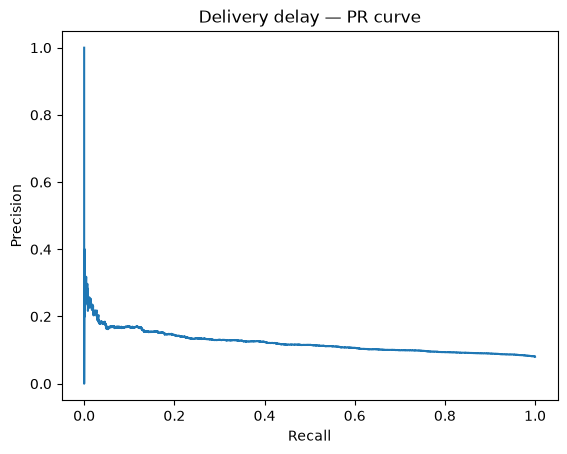

['model_delivery_delay.pkl']

In [15]:
train_df4 = df_delay[df_delay["is_synthetic"] == False].dropna(subset=["is_delayed"]).copy()
train_df4["is_delayed"] = train_df4["is_delayed"].astype(int)

num_cols4 = ["price", "freight_value", "n_items", "payment_installments",
             "purchase_day_of_week", "purchase_month", "promised_delivery_days"]
cat_cols4 = ["main_category", "payment_type", "seller_state"]

X4 = train_df4[num_cols4 + cat_cols4]
y4 = train_df4["is_delayed"]

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42, stratify=y4
)

preprocessor4 = ColumnTransformer([
    ("num", StandardScaler(), num_cols4),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols4),
])

clf_delay = Pipeline([
    ("prep", preprocessor4),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
clf_delay.fit(X4_train, y4_train)

y4_proba = clf_delay.predict_proba(X4_test)[:, 1]
y4_pred = clf_delay.predict(X4_test)

print(classification_report(y4_test, y4_pred))
print("PR-AUC:", average_precision_score(y4_test, y4_proba))

precision4, recall4, _ = precision_recall_curve(y4_test, y4_proba)
plt.plot(recall4, precision4)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Delivery delay — PR curve")
plt.show()

joblib.dump(clf_delay, "model_delivery_delay.pkl")